Monte Carlo Simulations. 

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import random
import importlib
import generativeAI
importlib.reload(generativeAI)
from generativeAI import *
%pip install kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Import R's GRF package
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
base = importr('base')
grf = importr('grf')

%pip install econml
%pip install xgboost
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor
from econml.dml import CausalForestDML
%pip install skorch
from skorch import NeuralNetRegressor, NeuralNetClassifier
from torch import nn
from econml.dml import NonParamDML
%pip install ganite
from ganite import Ganite
%pip install git+https://github.com/VadimSokolov/gbc.git
import gbc.causal
from gbc.causal import CausalIQN, CausalIQNv2, CausalEnsemble




Error importing in API mode: ImportError("dlopen(/Users/marnar/labrepos/generativeAI/.venv/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/marnar/labrepos/generativeAI/.venv/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Users/marnar/labrepos/generativeAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/VadimSokolov/gbc.git to /private/var/folders/pp/s0jy8nd16xj8fd7dzc5k_7p80000gn/T/pip-req-build-aggiugj6
  Running command git clone --filter=blob:none --quiet https://github.com/VadimSokolov/gbc.git /private/var/folders/pp/s0jy8nd16xj8fd7dzc5k_7p80000gn/T/pip-req

In [3]:
def simulate_causal_data(n_samples=500, 
                        n_features=4, treatment_type='observational', 
                        random_state=42, effect = "linear"):

    """Simulate Y = mu(X) + theta(X)*D + epsilon with known CATE."""
    rng = np.random.default_rng(random_state)
    X = rng.standard_normal((n_samples, n_features))
    beta_mu = rng.standard_normal(n_features) * 0.5
    mu = X @ beta_mu

    if effect == "linear":
        theta_true = 1.0 + X[:, 0] + 0.5 * X[:, 1]
    elif effect == "non-linear":
        theta_true = 1.0 + X[:, 0]**2 + 0.5 * X[:, 1]**2
    elif effect == "interaction":
        theta_true = 1.0 + X[:, 0] * X[:, 1]
    elif effect == "non-linear interaction":
        theta_true = 1.0 + X[:, 0]**2 * X[:, 1]
    if treatment_type == 'rct':
        D = rng.binomial(1, 0.5, n_samples)
    else:
        logit = 0.3 * X[:, 0] - 0.2 * X[:, 1]
        if n_features >= 3:
            logit += 0.1 * X[:, 2]
        p = 1 / (1 + np.exp(-logit))
        D = rng.binomial(1, p, n_samples)

    Y = mu + theta_true * D + rng.standard_normal(n_samples) * 0.5
    return X, D, Y, theta_true



Loop over effect types: linear, non-linear, interaction, non-linear interaction


--- LINEAR (100 MC replications) ---
GRF MSE:  0.38 ± 0.08
GANITE MSE: 0.93 ± 0.29
GenTE MSE: 0.09 ± 0.03

--- NON-LINEAR (100 MC replications) ---
GRF MSE:  1.89 ± 0.43
GANITE MSE: 5.08 ± 0.70
GenTE MSE: 0.25 ± 0.13

--- INTERACTION (100 MC replications) ---
GRF MSE:  0.95 ± 0.17
GANITE MSE: 1.29 ± 0.25
GenTE MSE: 0.30 ± 0.10

--- NON-LINEAR INTERACTION (100 MC replications) ---
GRF MSE:  2.43 ± 0.88
GANITE MSE: 3.18 ± 1.04
GenTE MSE: 1.52 ± 0.75


/var/folders/pp/s0jy8nd16xj8fd7dzc5k_7p80000gn/T/ipykernel_25270/956426532.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y='CATE', palette=['#8B0000', '#967BB6', '#E6A23C', '#4C787E'])


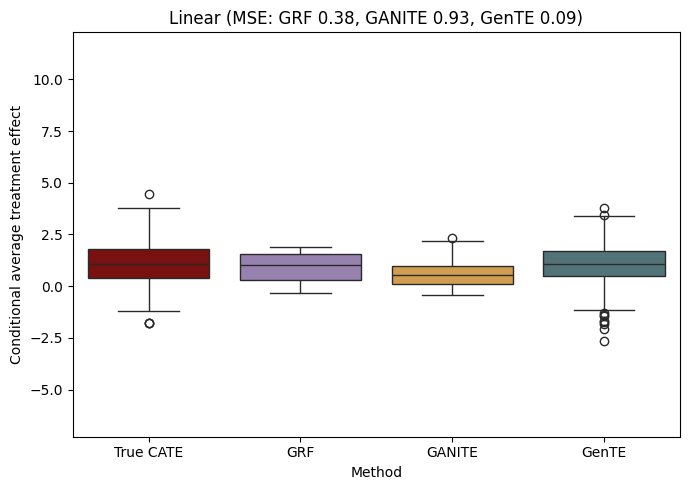

/var/folders/pp/s0jy8nd16xj8fd7dzc5k_7p80000gn/T/ipykernel_25270/956426532.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y='CATE', palette=['#8B0000', '#967BB6', '#E6A23C', '#4C787E'])


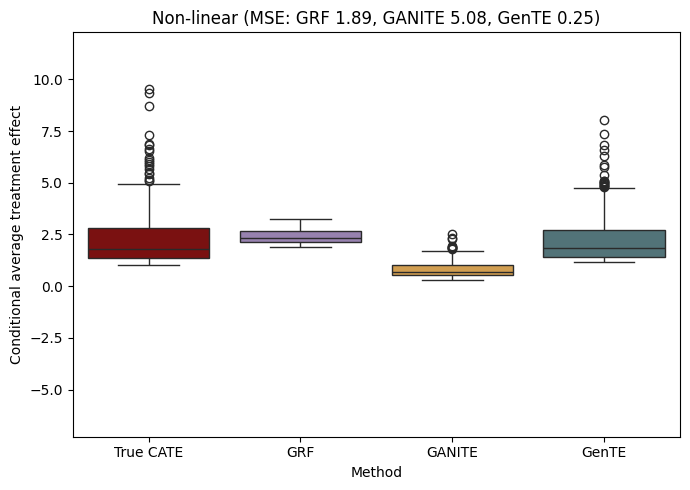

/var/folders/pp/s0jy8nd16xj8fd7dzc5k_7p80000gn/T/ipykernel_25270/956426532.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y='CATE', palette=['#8B0000', '#967BB6', '#E6A23C', '#4C787E'])


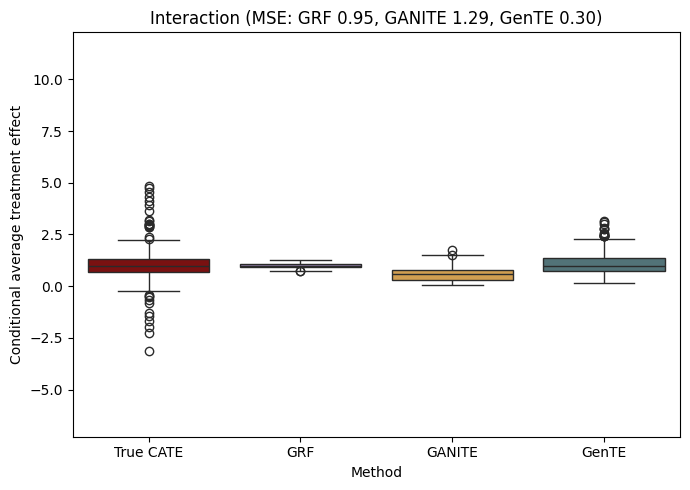

/var/folders/pp/s0jy8nd16xj8fd7dzc5k_7p80000gn/T/ipykernel_25270/956426532.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y='CATE', palette=['#8B0000', '#967BB6', '#E6A23C', '#4C787E'])


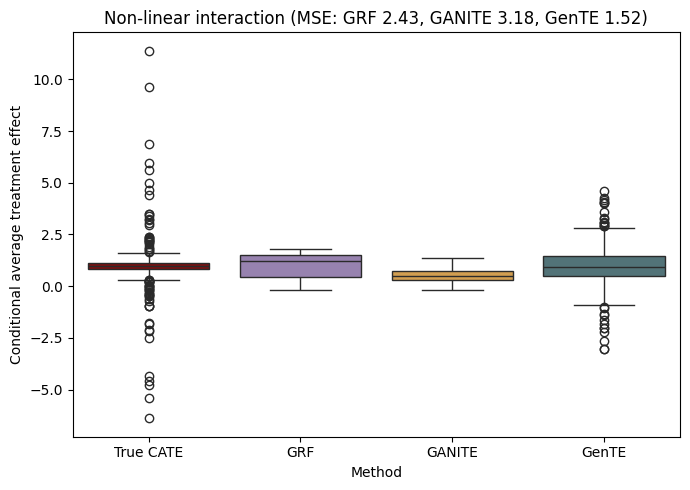

In [32]:
results_sims = 'results_sims'
os.makedirs(results_sims, exist_ok=True)

effect_types = ['linear', 'non-linear', 'interaction', 'non-linear interaction']
effect_labels = {'linear': 'Linear', 'non-linear': 'Non-linear', 'interaction': 'Interaction', 'non-linear interaction': 'Non-linear interaction'}
effect_filenames = {'linear': 'linear', 'non-linear': 'nonlinear', 'interaction': 'interaction', 'non-linear interaction': 'nonlinear_interaction'}
n_mc = 100  # Monte Carlo replications
SEED = 42
plot_data = {}

for effect in effect_types:
    print(f"\n--- {effect.upper()} ({n_mc} MC replications) ---")
    mse_grf_list, mse_ganite_list, mse_gen_list = [], [], []
    tau_test_plot = tau_grf_plot = tau_ganite_plot = tau_gen_plot = None  # for final plot

    for rep in range(n_mc):
        rng_rep = SEED + rep
        X, D, Y, tau_true = simulate_causal_data(n_samples=500, n_features=4, treatment_type='observational', effect=effect, random_state=rng_rep)
        X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
            X, D, Y, tau_true, test_size=0.5, random_state=rng_rep, stratify=D
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # GRF
        with localconverter(ro.default_converter + numpy2ri.converter):
            X_train_r = ro.r.matrix(X_train, nrow=X_train.shape[0], ncol=X_train.shape[1])
            D_train_r = ro.FloatVector(D_train)
            Y_train_r = ro.FloatVector(Y_train)
            X_test_r = ro.r.matrix(X_test, nrow=X_test.shape[0], ncol=X_test.shape[1])
            cf_sim = grf.causal_forest(X_train_r, Y_train_r, D_train_r, seed=rng_rep)
            pred_grf_sim = grf.predict_causal_forest(cf_sim, X_test_r)
            tau_grf_sim = np.array(pred_grf_sim.rx2('predictions') if hasattr(pred_grf_sim, 'rx2') else pred_grf_sim['predictions'])

        # GANITE
        model_ganite = Ganite(X_train, D_train, Y_train, num_iterations=500)
        tau_ganite_sim = np.asarray(model_ganite(X_test).numpy()).flatten()

        # GenerativeTE
        ens = CausalEnsemble(
            model_cls=CausalIQN,
            model_kwargs={"xdim": X_train.shape[1], "hsz": 64, "nh": 32},
            n_models=3,
            device="auto",
            )
        ens.fit(X_train, Y_train, D_train, epochs=500, lr=0.01,
                weight_decay=1e-3, verbose=False)
        qte_sim = ens.estimate_qte(X_test)
        tau_gen_sim = qte_sim.mean(axis=1).astype(np.float32)


        mse_grf = np.mean((tau_grf_sim - tau_test)**2)
        mse_ganite = np.mean((tau_ganite_sim - tau_test)**2)
        mse_gen = np.mean((tau_gen_sim - tau_test)**2)
        mse_grf_list.append(mse_grf)
        mse_ganite_list.append(mse_ganite)
        mse_gen_list.append(mse_gen)

        if rep == n_mc - 1:  # keep last rep for plot
            tau_test_plot, tau_grf_plot, tau_ganite_plot, tau_gen_plot = tau_test, tau_grf_sim, tau_ganite_sim, tau_gen_sim

    mse_grf_mean, mse_grf_std = np.mean(mse_grf_list), np.std(mse_grf_list)
    mse_ganite_mean, mse_ganite_std = np.mean(mse_ganite_list), np.std(mse_ganite_list)
    mse_gen_mean, mse_gen_std = np.mean(mse_gen_list), np.std(mse_gen_list)
    print(f"GRF MSE:  {mse_grf_mean:.2f} ± {mse_grf_std:.2f}")
    print(f"GANITE MSE: {mse_ganite_mean:.2f} ± {mse_ganite_std:.2f}")
    print(f"GenTE MSE: {mse_gen_mean:.2f} ± {mse_gen_std:.2f}")

    plot_data[effect] = (tau_test_plot, tau_grf_plot, tau_ganite_plot, tau_gen_plot, mse_grf_mean, mse_ganite_mean, mse_gen_mean)

# Shared y-scale across all effect types
all_vals = np.concatenate([np.concatenate([plot_data[e][0], plot_data[e][1], plot_data[e][2], plot_data[e][3]]) for e in effect_types])
y_min, y_max = np.min(all_vals), np.max(all_vals)
pad = (y_max - y_min) * 0.05 + 0.01
y_lim = (y_min - pad, y_max + pad)

for effect in effect_types:
    tau_test_plot, tau_grf_plot, tau_ganite_plot, tau_gen_plot, mse_grf_mean, mse_ganite_mean, mse_gen_mean = plot_data[effect]
    df_plot = pd.DataFrame({
        'True CATE': tau_test_plot,
        'GRF': tau_grf_plot,
        'GANITE': tau_ganite_plot,
        'GenTE': tau_gen_plot
    }).melt(var_name='Method', value_name='CATE')
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df_plot, x='Method', y='CATE', palette=['#8B0000', '#967BB6', '#E6A23C', '#4C787E'])
    plt.ylim(y_lim)
    plt.xlabel('Method')
    plt.ylabel('Conditional average treatment effect')
    plt.title(f"{effect_labels[effect]} (MSE: GRF {mse_grf_mean:.2f}, GANITE {mse_ganite_mean:.2f}, GenTE {mse_gen_mean:.2f})")
    plt.tight_layout()
    plt.savefig(os.path.join(results_sims, f'box_simulation_comparison_{effect_filenames[effect]}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(results_sims, f'box_simulation_comparison_{effect_filenames[effect]}.png'), dpi=300, bbox_inches='tight')
    plt.show()

## Plot CATEs

Table: MSE across effect types, sample sizes and covariate dimensions (100 MC)

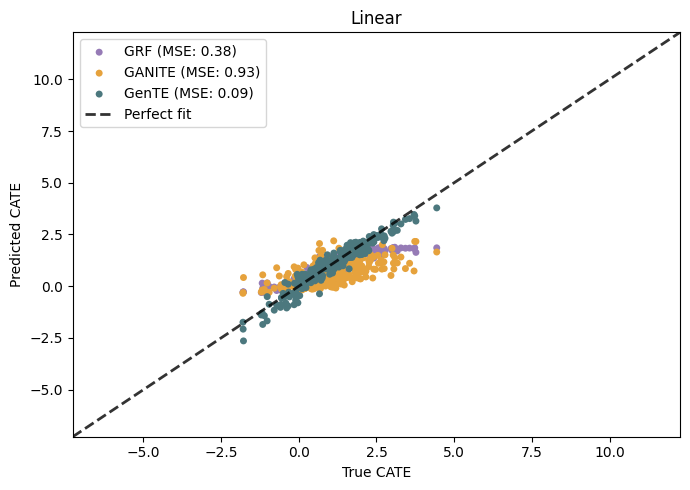

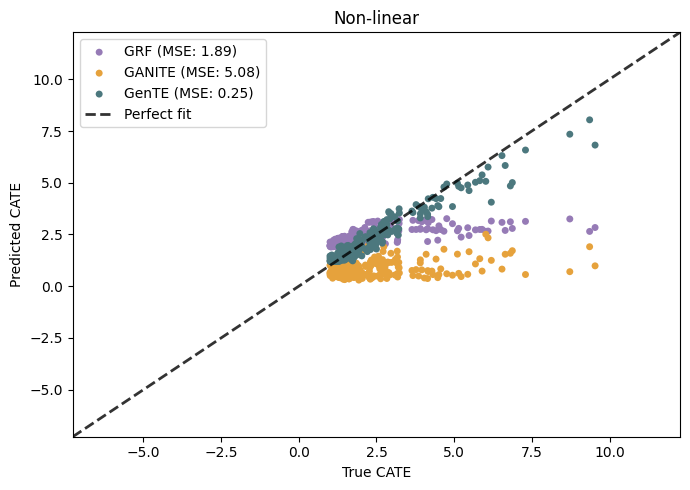

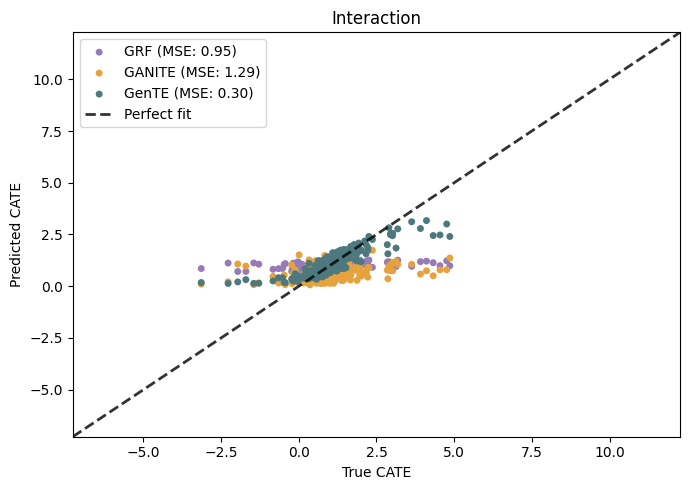

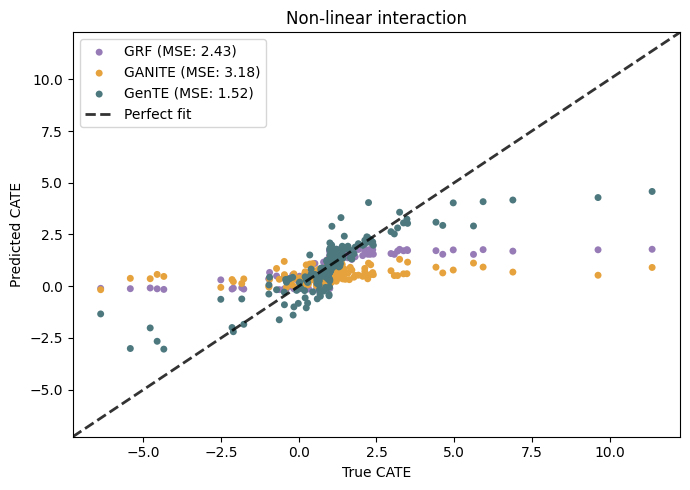

In [15]:
# Scatter: Predicted vs True CATE (uses plot_data from cell above)
# Run the simulation cell first, then this cell

for effect in effect_types:
    tau_test_plot, tau_grf_plot, tau_ganite_plot, tau_gen_plot, mse_grf_mean, mse_ganite_mean, mse_gen_mean = plot_data[effect]
    plt.figure(figsize=(7, 5))
    plt.scatter(tau_test_plot, tau_grf_plot, s=25, c='#967BB6', label=f'GRF (MSE: {mse_grf_mean:.2f})', edgecolors='none')
    plt.scatter(tau_test_plot, tau_ganite_plot, s=25, c='#E6A23C', label=f'GANITE (MSE: {mse_ganite_mean:.2f})', edgecolors='none')
    plt.scatter(tau_test_plot, tau_gen_plot, s=25, c='#4C787E', label=f'GenTE (MSE: {mse_gen_mean:.2f})', edgecolors='none')
    plt.plot(y_lim, y_lim, 'k--', linewidth=2, alpha=0.8, label='Perfect fit')
    plt.xlim(y_lim)
    plt.ylim(y_lim)
    plt.xlabel('True CATE')
    plt.ylabel('Predicted CATE')
    plt.title(f"{effect_labels[effect]}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(results_sims, f'scatter_simulation_comparison_{effect_filenames[effect]}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(results_sims, f'scatter_simulation_comparison_{effect_filenames[effect]}.png'), dpi=300, bbox_inches='tight')
    plt.show()

Comparison to Double/Debiased ML

In [18]:

# Table: MSE across effect types, sample sizes and covariate dimensions
SEED = 232
effect_types = ['linear', 'non-linear', 'interaction', 'non-linear interaction']
effect_labels = {
    'linear': 'Linear',
    'non-linear': 'Non-linear',
    'interaction': 'Interaction',
    'non-linear interaction': 'Non-linear interaction'
}
n_samples_list = [200, 500, 1000]
n_features_list = [2, 4, 8]
n_mc = 100  # Monte Carlo replications


rows = []
for effect in effect_types:
    for n_samples in n_samples_list:
        for n_features in n_features_list:
            mse_grf_list, mse_gen_list, mse_dml_list, mse_dml_nn_list = [], [], [], []
            for rep in range(n_mc):
                rng_rep = SEED + rep
                X, D, Y, tau_true = simulate_causal_data(
                    n_samples=n_samples, n_features=n_features,
                    treatment_type='observational', effect=effect, random_state=rng_rep
                )
                X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
                    X, D, Y, tau_true, test_size=0.5, random_state=rng_rep, stratify=D
                )
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

                # ---------------- GRF ----------------
                with localconverter(ro.default_converter + numpy2ri.converter):
                    X_train_r = ro.r.matrix(X_train, nrow=X_train.shape[0], ncol=X_train.shape[1])
                    D_train_r = ro.FloatVector(D_train)
                    Y_train_r = ro.FloatVector(Y_train)
                    X_test_r = ro.r.matrix(X_test, nrow=X_test.shape[0], ncol=X_test.shape[1])
                    cf = grf.causal_forest(X_train_r, Y_train_r, D_train_r, seed=SEED)
                    pred_grf = grf.predict_causal_forest(cf, X_test_r)
                    tau_grf = np.array(
                        pred_grf.rx2('predictions') if hasattr(pred_grf, 'rx2') else pred_grf['predictions']
                    )

                # ------------- GenerativeTE -------------
                ens = CausalEnsemble(
                    model_cls=CausalIQN,
                    model_kwargs={"xdim": X_train.shape[1], "hsz": 64, "nh": 32},
                    n_models=3,
                    device="auto",
                    )
                ens.fit(X_train, Y_train, D_train, epochs=500, lr=0.01,
                        weight_decay=1e-3, verbose=False)
                qte_sim = ens.estimate_qte(X_test)
                tau_gen = qte_sim.mean(axis=1).astype(np.float32)


                # ------------- DML with XGBoost nuisances -------------
                dml = CausalForestDML(
                    model_y=XGBRegressor(
                        n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=rng_rep
                    ),
                    model_t=RandomForestClassifier(
                        n_estimators=200, min_samples_leaf=5, random_state=rng_rep
                    ),
                    discrete_treatment=True,
                    n_estimators=500,
                    min_samples_leaf=5,
                    random_state=rng_rep,
                )
                dml.fit(Y_train, D_train, X=X_train)
                tau_dml = dml.effect(X_test)
                

                # Fit on your train split
                X_train_np = X_train.astype(np.float32)  # skorch wants float32
                Y_train_np = Y_train.astype(np.float32)

                
                # ------------- MSEs vs true CATE -------------
                mse_grf = np.mean((tau_grf - tau_test)**2)
                mse_gen = np.mean((tau_gen - tau_test)**2)
                mse_dml = np.mean((tau_dml - tau_test)**2)

                mse_grf_list.append(mse_grf)
                mse_gen_list.append(mse_gen)
                mse_dml_list.append(mse_dml)



            rows.append({
                'effect': effect,
                'n_samples': n_samples,
                'n_features': n_features,
                'GRF MSE':        np.mean(mse_grf_list),
                'GRF MSE std':    np.std(mse_grf_list),
                'GenTE MSE':      np.mean(mse_gen_list),
                'GenTE MSE std':  np.std(mse_gen_list),
                'DML MSE':        np.mean(mse_dml_list),
                'DML MSE std':    np.std(mse_dml_list)
            })

df_table = pd.DataFrame(rows)

# Print by effect (including both DML variants)
for effect in effect_types:
    df_e = df_table[df_table['effect'] == effect]
    print(f"\n--- {effect_labels[effect].upper()} ---")
    for _, row in df_e.iterrows():
        print(
            f"  n={row['n_samples']}, p={row['n_features']}: "
            f"GRF {row['GRF MSE']:.4f} ± {row['GRF MSE std']:.4f} | "
            f"GenTE {row['GenTE MSE']:.4f} ± {row['GenTE MSE std']:.4f} | "
            f"DML-XGB {row['DML MSE']:.4f} ± {row['DML MSE std']:.4f} | "
        )


--- LINEAR ---
  n=200, p=2: GRF 0.8001 ± 0.1879 | GenTE 0.1304 ± 0.0826 | DML-XGB 0.4645 ± 0.1476 | 
  n=200, p=4: GRF 0.8605 ± 0.1877 | GenTE 0.3021 ± 0.1716 | DML-XGB 0.6100 ± 0.1665 | 
  n=200, p=8: GRF 0.9938 ± 0.2219 | GenTE 0.8105 ± 0.2254 | DML-XGB 0.8082 ± 0.2149 | 
  n=500, p=2: GRF 0.2978 ± 0.0627 | GenTE 0.0595 ± 0.0451 | DML-XGB 0.2252 ± 0.0703 | 
  n=500, p=4: GRF 0.3542 ± 0.0671 | GenTE 0.1022 ± 0.0436 | DML-XGB 0.2814 ± 0.0670 | 
  n=500, p=8: GRF 0.4999 ± 0.1299 | GenTE 0.2487 ± 0.0699 | DML-XGB 0.4188 ± 0.1155 | 
  n=1000, p=2: GRF 0.1611 ± 0.0337 | GenTE 0.0363 ± 0.0261 | DML-XGB 0.1262 ± 0.0328 | 
  n=1000, p=4: GRF 0.2030 ± 0.0387 | GenTE 0.0462 ± 0.0154 | DML-XGB 0.1609 ± 0.0374 | 
  n=1000, p=8: GRF 0.2926 ± 0.0709 | GenTE 0.1132 ± 0.0332 | DML-XGB 0.2421 ± 0.0583 | 

--- NON-LINEAR ---
  n=200, p=2: GRF 2.6463 ± 0.9430 | GenTE 0.4719 ± 0.4426 | DML-XGB 2.3809 ± 0.9527 | 
  n=200, p=4: GRF 2.5285 ± 0.7011 | GenTE 0.6907 ± 0.3657 | DML-XGB 2.3725 ± 0.6641 | 
  n=

Plot with DML-XGB


--- LINEAR (100 MC replications) ---
GRF MSE:  1.69 ±0.16
GenTE MSE: 0.09 ± 0.03


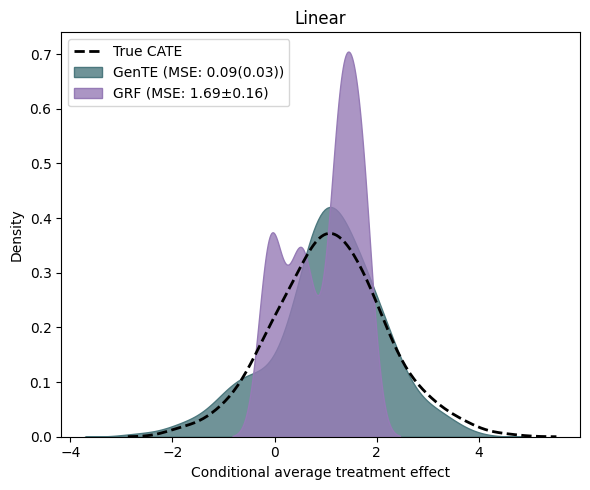


--- NON-LINEAR (100 MC replications) ---
GRF MSE:  5.41 ±0.70
GenTE MSE: 0.25 ± 0.13


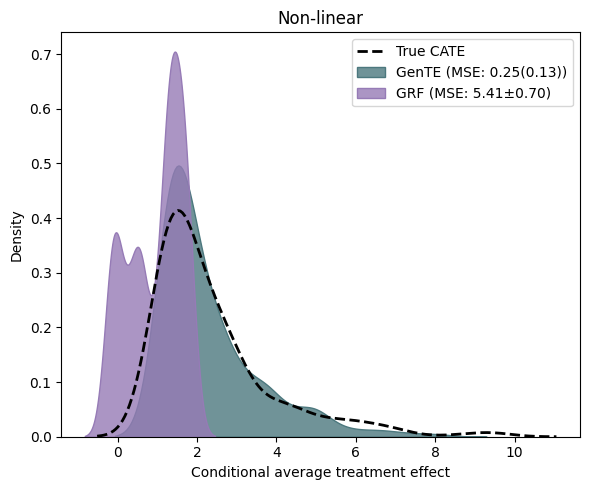


--- INTERACTION (100 MC replications) ---
GRF MSE:  1.46 ±0.19
GenTE MSE: 0.30 ± 0.10


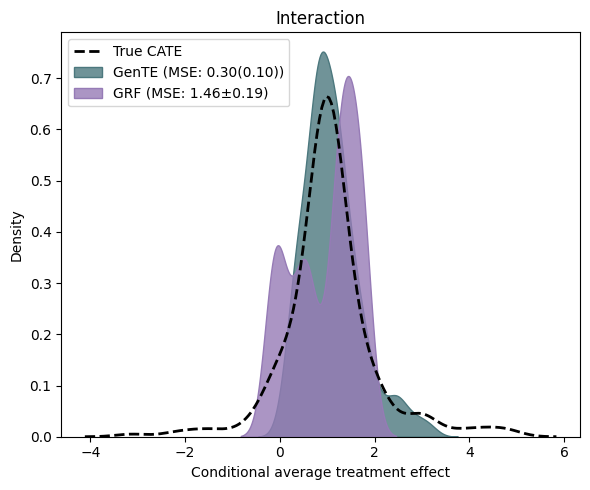


--- NON-LINEAR INTERACTION (100 MC replications) ---
GRF MSE:  3.60 ±0.99
GenTE MSE: 1.52 ± 0.75


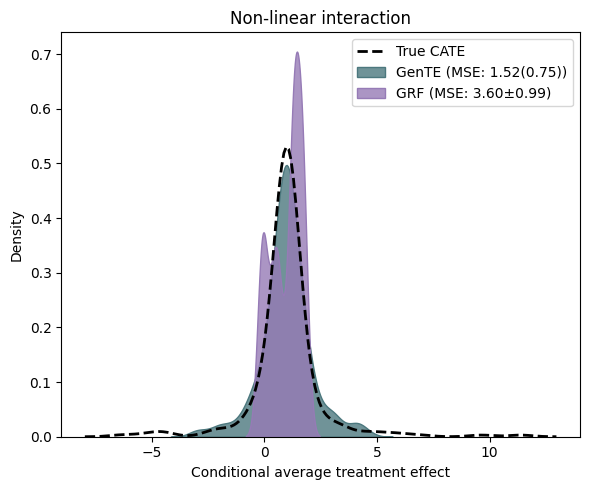

In [19]:
results_sims = 'results_sims'
os.makedirs(results_sims, exist_ok=True)

effect_types = ['linear', 'non-linear', 'interaction', 'non-linear interaction']
effect_labels = {'linear': 'Linear', 'non-linear': 'Non-linear', 'interaction': 'Interaction', 'non-linear interaction': 'Non-linear interaction'}
effect_filenames = {'linear': 'linear', 'non-linear': 'nonlinear', 'interaction': 'interaction', 'non-linear interaction': 'nonlinear_interaction'}
n_mc = 100  # Monte Carlo replications
SEED = 42

for effect in effect_types:
    print(f"\n--- {effect.upper()} ({n_mc} MC replications) ---")
    mse_grf_list, mse_gen_list = [], []
    tau_test_plot = tau_grf_plot = tau_gen_plot = None  # for final plot

    for rep in range(n_mc):
        rng_rep = SEED + rep
        X, D, Y, tau_true = simulate_causal_data(n_samples=500, n_features=4, treatment_type='observational', effect=effect, random_state=rng_rep)
        X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
            X, D, Y, tau_true, test_size=0.5, random_state=rng_rep, stratify=D
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # ------------- DML with XGBoost nuisances -------------
        dml = CausalForestDML(
            model_y=XGBRegressor(
                n_estimators=300, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                random_state=rng_rep
            ),
            model_t=RandomForestClassifier(
                n_estimators=200, min_samples_leaf=5, random_state=rng_rep
            ),
            discrete_treatment=True,
            n_estimators=500,
            min_samples_leaf=5,
            random_state=rng_rep,
        )
        dml.fit(Y_train, D_train, X=X_train)
        tau_dml = dml.effect(X_test)

        
        # GenerativeTE
        ens = CausalEnsemble(
            model_cls=CausalIQN,
            model_kwargs={"xdim": X_train.shape[1], "hsz": 64, "nh": 32},
            n_models=3,
            device="auto",
            )
        ens.fit(X_train, Y_train, D_train, epochs=500, lr=0.01,
                weight_decay=1e-3, verbose=False)
        qte_sim = ens.estimate_qte(X_test)
        tau_gen_sim = qte_sim.mean(axis=1).astype(np.float32)


        mse_grf = np.mean((tau_grf_sim - tau_test)**2)
        mse_gen = np.mean((tau_gen_sim - tau_test)**2)
        mse_grf_list.append(mse_grf)
        mse_gen_list.append(mse_gen)

        if rep == n_mc - 1:  # keep last rep for plot
            tau_test_plot, tau_grf_plot, tau_gen_plot = tau_test, tau_grf_sim, tau_gen_sim

    mse_grf_mean, mse_grf_std = np.mean(mse_grf_list), np.std(mse_grf_list)
    mse_gen_mean, mse_gen_std = np.mean(mse_gen_list), np.std(mse_gen_list)
    print(f"GRF MSE:  {mse_grf_mean:.2f} ±{mse_grf_std:.2f}")
    print(f"GenTE MSE: {mse_gen_mean:.2f} ± {mse_gen_std:.2f}")

    # Plot (from last replication)
    plt.figure(figsize=(6, 5))
    sns.kdeplot(tau_test_plot, label='True CATE', color='black', linestyle='--', linewidth=2)
    sns.kdeplot(tau_gen_plot, label=f'GenTE (MSE: {mse_gen_mean:.2f}({mse_gen_std:.2f}))', color='#4C787E', fill=True, alpha=0.8)
    sns.kdeplot(tau_grf_plot, label=f'GRF (MSE: {mse_grf_mean:.2f}±{mse_grf_std:.2f})', color='#967BB6', fill=True, alpha=0.8)
    plt.title(effect_labels[effect])
    plt.xlabel('Conditional average treatment effect')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(results_sims, f'simulation_comparison_{effect_filenames[effect]}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(results_sims, f'simulation_comparison_{effect_filenames[effect]}.png'), dpi=300, bbox_inches='tight')
    plt.show()


Comparison to GANITE


--- LINEAR (100 MC replications) ---
GanITE MSE:  0.93 ± 0.29
GenTE MSE: 0.09 ± 0.03


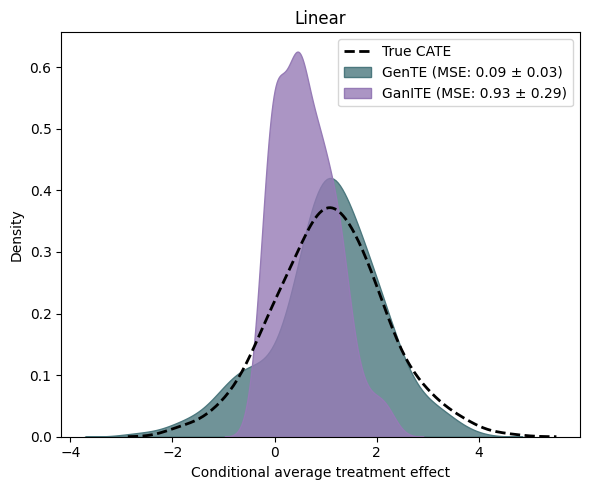


--- NON-LINEAR (100 MC replications) ---
GanITE MSE:  5.08 ± 0.70
GenTE MSE: 0.25 ± 0.13


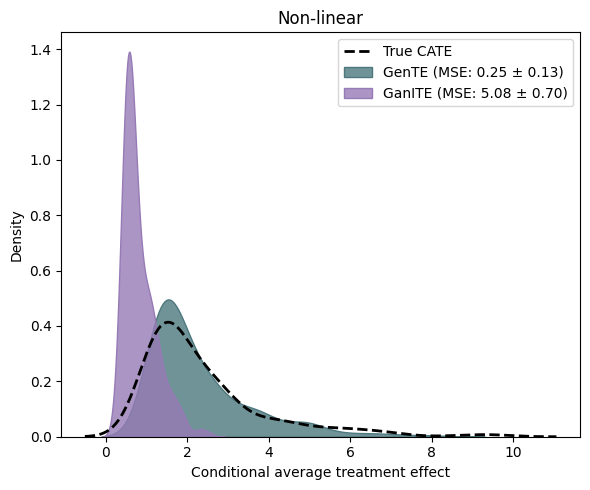


--- INTERACTION (100 MC replications) ---
GanITE MSE:  1.29 ± 0.25
GenTE MSE: 0.30 ± 0.10


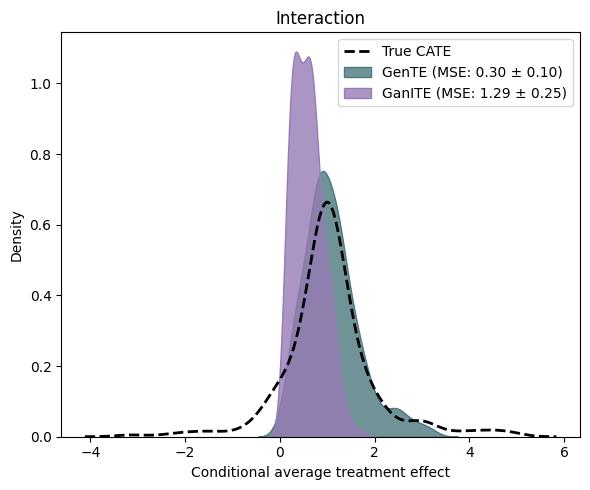


--- NON-LINEAR INTERACTION (100 MC replications) ---
GanITE MSE:  3.18 ± 1.04
GenTE MSE: 1.52 ± 0.75


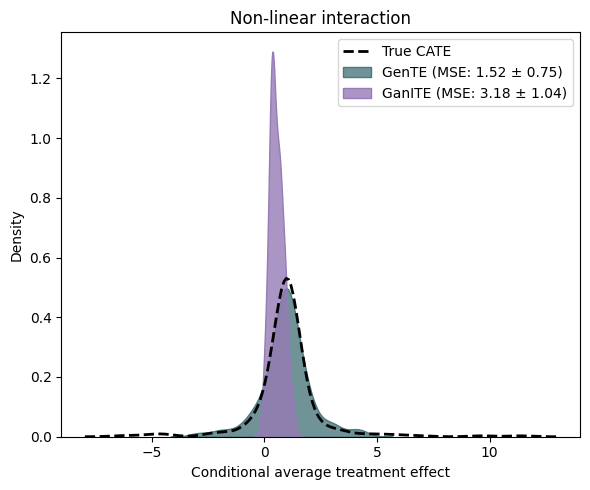

In [20]:
results_sims = 'results_sims'
os.makedirs(results_sims, exist_ok=True)

effect_types = ['linear', 'non-linear', 'interaction', 'non-linear interaction']
effect_labels = {'linear': 'Linear', 'non-linear': 'Non-linear', 'interaction': 'Interaction', 'non-linear interaction': 'Non-linear interaction'}
effect_filenames = {'linear': 'linear', 'non-linear': 'nonlinear', 'interaction': 'interaction', 'non-linear interaction': 'nonlinear_interaction'}
n_mc = 100  # Monte Carlo replications
SEED = 42

for effect in effect_types:
    print(f"\n--- {effect.upper()} ({n_mc} MC replications) ---")
    mse_ganite_list, mse_gen_list = [], []
    tau_test_plot = tau_ganite_plot = tau_gen_plot = None  # for final plot

    for rep in range(n_mc):
        rng_rep = SEED + rep
        X, D, Y, tau_true = simulate_causal_data(n_samples=500, n_features=4, treatment_type='observational', effect=effect, random_state=rng_rep)
        X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
            X, D, Y, tau_true, test_size=0.5, random_state=rng_rep, stratify=D
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # GANITE
        model = Ganite(X_train, D_train, Y_train, num_iterations=500)
        tau_ganite = np.asarray(model(X_test).numpy()).flatten()


        # GenerativeTE
        ens = CausalEnsemble(
            model_cls=CausalIQN,
            model_kwargs={"xdim": X_train.shape[1], "hsz": 64, "nh": 32},
            n_models=3,
            device="auto",
            )
        ens.fit(X_train, Y_train, D_train, epochs=500, lr=0.01,
                weight_decay=1e-3, verbose=False)
        qte_sim = ens.estimate_qte(X_test)
        tau_gen_sim = qte_sim.mean(axis=1).astype(np.float32)


        mse_ganite = np.mean((tau_ganite - tau_test)**2)
        mse_gen = np.mean((tau_gen_sim - tau_test)**2)
        mse_ganite_list.append(mse_ganite)
        mse_gen_list.append(mse_gen)

        if rep == n_mc - 1:  # keep last rep for plot
            tau_test_plot, tau_ganite_plot, tau_gen_plot = tau_test, tau_ganite, tau_gen_sim

    mse_ganite_mean, mse_ganite_std = np.mean(mse_ganite_list), np.std(mse_ganite_list)
    mse_gen_mean, mse_gen_std = np.mean(mse_gen_list), np.std(mse_gen_list)
    print(f"GanITE MSE:  {mse_ganite_mean:.2f} ± {mse_ganite_std:.2f}")
    print(f"GenTE MSE: {mse_gen_mean:.2f} ± {mse_gen_std:.2f}")

    # Plot (from last replication)
    plt.figure(figsize=(6, 5))
    sns.kdeplot(tau_test_plot, label='True CATE', color='black', linestyle='--', linewidth=2)
    sns.kdeplot(tau_gen_plot, label=f'GenTE (MSE: {mse_gen_mean:.2f} ± {mse_gen_std:.2f})', color='#4C787E', fill=True, alpha=0.8)
    sns.kdeplot(tau_ganite_plot, label=f'GanITE (MSE: {mse_ganite_mean:.2f} ± {mse_ganite_std:.2f})', color='#967BB6', fill=True, alpha=0.8)
    plt.title(effect_labels[effect])
    plt.xlabel('Conditional average treatment effect')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(results_sims, f'ganite_simulation_comparison_{effect_filenames[effect]}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(results_sims, f'ganite_simulation_comparison_{effect_filenames[effect]}.png'), dpi=300, bbox_inches='tight')
    plt.show()


In [21]:
# Table: MSE comparison GenTE (estimate_qte_separate) vs GenTE (estimate_qte)
from gbc.iqn import train_iqn

SEED = 232
effect_types = ['linear', 'non-linear', 'interaction', 'non-linear interaction']
effect_labels = {
    'linear': 'Linear',
    'non-linear': 'Non-linear',
    'interaction': 'Interaction',
    'non-linear interaction': 'Non-linear interaction'
}
n_samples_list = [200, 500, 1000]
n_features_list = [2, 4, 8]
n_mc = 100  # Monte Carlo replications

rows = []
for effect in effect_types:
    for n_samples in n_samples_list:
        for n_features in n_features_list:
            mse_ganite_list, mse_gen_list = [], []
            for rep in range(n_mc):
                rng_rep = SEED + rep
                X, D, Y, tau_true = simulate_causal_data(
                    n_samples=n_samples, n_features=n_features,
                    treatment_type='observational', effect=effect, random_state=rng_rep
                )
                X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
                    X, D, Y, tau_true, test_size=0.5, random_state=rng_rep, stratify=D
                )
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

                # ------------- GenTE (estimate_qte_separate) -------------
                # Same two-IQN recipe as CausalEnsemble.estimate_qte_separate,
                # trained on the train fold and scored on X_test.
                Z_tr = np.asarray(D_train).ravel()
                Y_tr = np.asarray(Y_train).ravel()
                m1, xm1, xs1, ym1, ys1 = train_iqn(
                    X_train[Z_tr == 1], Y_tr[Z_tr == 1],
                    epochs=500, hdim=64, nh=32, seed=rng_rep)
                m0, xm0, xs0, ym0, ys0 = train_iqn(
                    X_train[Z_tr == 0], Y_tr[Z_tr == 0],
                    epochs=500, hdim=64, nh=32, seed=rng_rep + 1)
                qs = np.linspace(0.05, 0.95, 19)
                X1t = torch.tensor((X_test - xm1) / xs1, dtype=torch.float32)
                X0t = torch.tensor((X_test - xm0) / xs0, dtype=torch.float32)
                qte_sep = np.zeros((X_test.shape[0], len(qs)))
                with torch.no_grad():
                    for j, q in enumerate(qs):
                        f1 = m1(X1t, q)[:, 1].numpy() * ys1 + ym1
                        f0 = m0(X0t, q)[:, 1].numpy() * ys0 + ym0
                        qte_sep[:, j] = f1 - f0
                tau_ganite = qte_sep.mean(axis=1).astype(np.float32)

                # ------------- GenTE -------------
                ens = CausalEnsemble(
                    model_cls=CausalIQN,
                    model_kwargs={"xdim": X_train.shape[1], "hsz": 64, "nh": 32},
                    n_models=3,
                    device="auto",
                    )
                ens.fit(X_train, Y_train, D_train, epochs=500, lr=0.01,
                        weight_decay=1e-3, verbose=False)
                qte_sim = ens.estimate_qte(X_test)
                tau_gen = qte_sim.mean(axis=1).astype(np.float32)


                # ------------- MSEs vs true CATE -------------
                mse_ganite = np.mean((tau_ganite - tau_test)**2)
                mse_gen = np.mean((tau_gen - tau_test)**2)
                mse_ganite_list.append(mse_ganite)
                mse_gen_list.append(mse_gen)

            rows.append({
                'effect': effect,
                'n_samples': n_samples,
                'n_features': n_features,
                'GanITE MSE': np.mean(mse_ganite_list),
                'GanITE MSE std': np.std(mse_ganite_list),
                'GenTE MSE': np.mean(mse_gen_list),
                'GenTE MSE std': np.std(mse_gen_list),
            })

df_table_ganite_gen = pd.DataFrame(rows)

# Print by effect
for effect in effect_types:
    df_e = df_table_ganite_gen[df_table_ganite_gen['effect'] == effect]
    print(f"\n--- {effect_labels[effect].upper()} ---")
    for _, row in df_e.iterrows():
        print(
            f"  n={row['n_samples']}, p={row['n_features']}: "
            f"GenTE-sep {row['GanITE MSE']:.4f} ± {row['GanITE MSE std']:.4f} | "
            f"GenTE {row['GenTE MSE']:.4f} ± {row['GenTE MSE std']:.4f}"
        )


--- LINEAR ---
  n=200, p=2: GanITE 1.0295 ± 0.3622 | GenTE 0.1304 ± 0.0826
  n=200, p=4: GanITE 0.8738 ± 0.2938 | GenTE 0.3021 ± 0.1716
  n=200, p=8: GanITE 1.1235 ± 0.3812 | GenTE 0.8105 ± 0.2254
  n=500, p=2: GanITE 0.9866 ± 0.2869 | GenTE 0.0595 ± 0.0451
  n=500, p=4: GanITE 0.8888 ± 0.3297 | GenTE 0.1022 ± 0.0436
  n=500, p=8: GanITE 1.1180 ± 0.3441 | GenTE 0.2487 ± 0.0699
  n=1000, p=2: GanITE 1.0441 ± 0.3737 | GenTE 0.0363 ± 0.0261
  n=1000, p=4: GanITE 0.8549 ± 0.2715 | GenTE 0.0462 ± 0.0154
  n=1000, p=8: GanITE 1.1266 ± 0.3196 | GenTE 0.1132 ± 0.0332

--- NON-LINEAR ---
  n=200, p=2: GanITE 5.0973 ± 1.2927 | GenTE 0.4719 ± 0.4426
  n=200, p=4: GanITE 4.9521 ± 1.0419 | GenTE 0.6907 ± 0.3657
  n=200, p=8: GanITE 4.9952 ± 1.1518 | GenTE 1.8958 ± 0.7506
  n=500, p=2: GanITE 4.9262 ± 0.7757 | GenTE 0.1820 ± 0.1234
  n=500, p=4: GanITE 4.7655 ± 0.6630 | GenTE 0.2409 ± 0.1252
  n=500, p=8: GanITE 5.0303 ± 0.7562 | GenTE 0.5288 ± 0.2137
  n=1000, p=2: GanITE 4.8770 ± 0.5567 | GenTE 

In [23]:
# Generate LaTeX MSE table from simulation results (run after GRF+DML+GenTE and GANITE+GenTE cells)
import sys
sys.path.insert(0, 'results_sims')
from mse_table_to_latex import mse_table_to_latex, merge_grf_dml_gente_with_ganite

df_full = merge_grf_dml_gente_with_ganite(df_table, df_table_ganite_gen)
print(df_full)
mse_table_to_latex(df_full, outpath='results_sims/mse_table_with_ganite.tex')


                    effect  n_samples  n_features   GRF MSE  GRF MSE std  \
0                   linear        200           2  0.800077     0.187876   
1                   linear        200           4  0.860540     0.187675   
2                   linear        200           8  0.993849     0.221876   
3                   linear        500           2  0.297835     0.062749   
4                   linear        500           4  0.354163     0.067146   
5                   linear        500           8  0.499907     0.129938   
6                   linear       1000           2  0.161121     0.033662   
7                   linear       1000           4  0.203020     0.038739   
8                   linear       1000           8  0.292551     0.070942   
9               non-linear        200           2  2.646259     0.943028   
10              non-linear        200           4  2.528549     0.701079   
11              non-linear        200           8  2.525030     0.765926   
12          

'\\begin{table}[H]\n\\centering\n\\caption{Mean squared error (MSE) of the generalised random forest (GRF), double machine learning based on XGBoost (DML-XGB), GANITE, and GenTE for different effect types, sample sizes $n$, and covariate dimensions $p$. Each cell reports the mean MSE with standard deviation in parentheses based on 100 Monte Carlo experiments. The last three columns report the average percent gain of GenTE relative to (i) GRF, (ii) DML-XGB, and (iii) GANITE, averaged over $p\\in\\{2,4,8\\}$ in each row.}\n\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}{lrrrrrrrrrrrrrrr}\n\\toprule\n& \\multicolumn{3}{c}{GRF} & \\multicolumn{3}{c}{DML-XGB} & \\multicolumn{3}{c}{GANITE} & \\multicolumn{3}{c}{GenTE} & \\multicolumn{3}{c}{Avg.\\ \\% gain (GenTE)} \\\\\n\\cmidrule(lr){2-4}\\cmidrule(lr){5-7}\\cmidrule(lr){8-10}\\cmidrule(lr){11-13}\\cmidrule(lr){14-16}\nSample size\n& $p{=}2$ & $p{=}4$ & $p{=}8$\n& $p{=}2$ & $p{=}4$ & $p{=}8$\n& $p{=}2$ & $p{=}4$ & $p{=}8$\n& $p{=}2$ & $p{=}

# Does Joint Estimation Improve Upon Separately Estimating Conditional Densities?

We find substantial improvement of jointly estimating the parameters when compared to a T-learner with separate quantile-level estimates for each arm.

In [10]:
# Table: MSE comparison GANITE vs GenTE
from ganite import Ganite

SEED = 232
effect_types = ['linear', 'non-linear', 'interaction', 'non-linear interaction']
effect_labels = {
    'linear': 'Linear',
    'non-linear': 'Non-linear',
    'interaction': 'Interaction',
    'non-linear interaction': 'Non-linear interaction'
}
n_samples_list = [200, 500, 1000]
n_features_list = [2, 4, 8]
n_mc = 100  # Monte Carlo replications

rows = []
for effect in effect_types:
    print("Effect:", effect)
    for n_samples in n_samples_list:
        for n_features in n_features_list:
            mse_gen_sep_list, mse_gen_joint_list = [], []
            for rep in range(n_mc):
                rng_rep = SEED + rep
                X, D, Y, tau_true = simulate_causal_data(
                    n_samples=n_samples, n_features=n_features,
                    treatment_type='observational', effect=effect, random_state=rng_rep
                )
                X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
                    X, D, Y, tau_true, test_size=0.5, random_state=rng_rep, stratify=D
                )
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

                # ------------- GENTE separate estimation -------------
                ens_sep = CausalEnsemble(
                    model_cls=CausalIQN,
                    model_kwargs={"xdim": X_train.shape[1], "hsz": 64, "nh": 32},
                    n_models=3,
                    device="auto",
                    )

                qte_sim_sep = ens_sep.estimate_qte_separate(
                    X_test, Y_test, D_test, epochs=100, hdim=64, nh=32,
                )
                tau_gen_sep = qte_sim_sep.mean(axis=1).astype(np.float32)



                # ------------- GenTE JOINT ESTIMATION -------------
                ens = CausalEnsemble(
                    model_cls=CausalIQN,
                    model_kwargs={"xdim": X_train.shape[1], "hsz": 64, "nh": 32},
                    n_models=3,
                    device="auto",
                    )
                ens.fit(X_train, Y_train, D_train, epochs=500, lr=0.01,
                        weight_decay=1e-3, verbose=False)
                qte_sim = ens.estimate_qte(X_test)
                tau_gen_joint = qte_sim.mean(axis=1).astype(np.float32)


                # ------------- MSEs vs true CATE -------------
                mse_gen_sep = np.mean((tau_gen_sep - tau_test)**2)
                mse_gen_joint = np.mean((tau_gen_joint - tau_test)**2)
                mse_gen_sep_list.append(mse_gen_sep)
                mse_gen_joint_list.append(mse_gen_joint)

            rows.append({
                'effect': effect,
                'n_samples': n_samples,
                'n_features': n_features,
                'GenTE Separate MSE': np.mean(mse_gen_sep_list),
                'GenTE Separate MSE std': np.std(mse_gen_sep_list),
                'GenTE Joint Estimation MSE': np.mean(mse_gen_joint_list),
                'GenTE Joint Estimation MSE std': np.std(mse_gen_joint_list),
            })

df_table_ganite_gen = pd.DataFrame(rows)

# Print by effect
for effect in effect_types:
    df_e = df_table_ganite_gen[df_table_ganite_gen['effect'] == effect]
    print(f"\n--- {effect_labels[effect].upper()} ---")
    for _, row in df_e.iterrows():
        print(
            f"  n={row['n_samples']}, p={row['n_features']}: "
            f"GenTE Separate Estimation {row['GenTE Separate MSE']:.4f} ± {row['GenTE Separate MSE std']:.4f} | "
            f"GenTE {row['GenTE Joint Estimation MSE']:.4f} ± {row['GenTE Joint Estimation MSE std']:.4f}"
        )

Effect: linear
Effect: non-linear
Effect: interaction
Effect: non-linear interaction

--- LINEAR ---
  n=200, p=2: GenTE Separate Estimation 0.7216 ± 0.1631 | GenTE 0.1335 ± 0.0811
  n=200, p=4: GenTE Separate Estimation 1.1238 ± 0.3347 | GenTE 0.3169 ± 0.1724
  n=200, p=8: GenTE Separate Estimation 1.1508 ± 0.3303 | GenTE 0.7679 ± 0.2099
  n=500, p=2: GenTE Separate Estimation 0.6755 ± 0.1220 | GenTE 0.0551 ± 0.0308
  n=500, p=4: GenTE Separate Estimation 1.0678 ± 0.2004 | GenTE 0.1098 ± 0.0421
  n=500, p=8: GenTE Separate Estimation 1.1242 ± 0.1454 | GenTE 0.2479 ± 0.0688
  n=1000, p=2: GenTE Separate Estimation 0.6805 ± 0.1111 | GenTE 0.0335 ± 0.0211
  n=1000, p=4: GenTE Separate Estimation 1.0540 ± 0.1852 | GenTE 0.0489 ± 0.0158
  n=1000, p=8: GenTE Separate Estimation 1.1148 ± 0.1421 | GenTE 0.1131 ± 0.0309

--- NON-LINEAR ---
  n=200, p=2: GenTE Separate Estimation 2.4345 ± 0.9233 | GenTE 0.4482 ± 0.4155
  n=200, p=4: GenTE Separate Estimation 2.4937 ± 0.7311 | GenTE 0.7088 ± 0.3

In [14]:
import importlib
import sys
sys.path.insert(0, 'results_sims')
import mse_table_to_latex
importlib.reload(mse_table_to_latex)
from mse_table_to_latex import gente_sep_joint_to_latex

tex = gente_sep_joint_to_latex(
    df_table_ganite_gen,
    outpath='results_sims/mse_table_gente_sep_joint.tex',
)
print(tex)


\begin{table}[H]
\centering
\caption{Mean squared error of GenTE with separate treated/control quantile functions versus joint estimation, by effect type, sample size $n$, and covariate dimension $p$. Each cell is the mean MSE (standard deviation in parentheses) over 100 Monte Carlo replications.}
\label{tab:gente_sep_joint}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrr}
\toprule
& \multicolumn{3}{c}{GenTE (separate)} & \multicolumn{3}{c}{GenTE (joint)} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
Sample size & $p{=}2$ & $p{=}4$ & $p{=}8$ & $p{=}2$ & $p{=}4$ & $p{=}8$ \\
\midrule
\multicolumn{7}{l}{Linear} \\
\midrule
200 & 0.722 & 1.124 & 1.151 & 0.134 & 0.317 & 0.768 \\
  & (0.163) & (0.335) & (0.330) & (0.081) & (0.172) & (0.210) \\
500 & 0.676 & 1.068 & 1.124 & 0.055 & 0.110 & 0.248 \\
  & (0.122) & (0.200) & (0.145) & (0.031) & (0.042) & (0.069) \\
1000 & 0.680 & 1.054 & 1.115 & 0.034 & 0.049 & 0.113 \\
  & (0.111) & (0.185) & (0.142) & (0.021) & (0.016) & (0.031) \\
\addlinespac

# Alternative Treatment Assignment Mechanisms

In [ ]:

import importlib
import generativeAI
importlib.reload(generativeAI)
from generativeAI import simulate_causal_assignments


SEED = 232
assignment_types = ['rct', 'logit', 'nonlinear', 'trig']
assignment_labels = {
    'rct': 'RCT',
    'logit': 'Linear logit',
    'nonlinear': 'Nonlinear logit',
    'trig': 'Trigonometric',
}
n_samples = 500
n_features = 20
n_mc = 100

rows = []
mse_records = []
for assignment in assignment_types:
    print('Assignment:', assignment)
    mse_list = []
    for rep in range(n_mc):
        rng_rep = SEED + rep
        X, D, Y, tau_true = simulate_causal_assignments(
            n_samples=n_samples,
            n_features=n_features,
            treatment_type=assignment,
            effect='non-linear interaction',
            random_state=rng_rep,
        )
        X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
            X, D, Y, tau_true, test_size=0.5, random_state=rng_rep, stratify=D,
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        ens = CausalEnsemble(
            model_cls=CausalIQN,
            model_kwargs={'xdim': X_train.shape[1], 'hsz': 64, 'nh': 32},
            n_models=3,
            device='auto',
        )
        ens.fit(X_train, Y_train, D_train, epochs=500, lr=0.01,
                weight_decay=1e-3, verbose=False)
        tau_hat = ens.estimate_qte(X_test).mean(axis=1).astype(np.float32)
        mse_list.append(np.mean((tau_hat - tau_test)**2))

    for mse in mse_list:
        mse_records.append({'assignment': assignment, 'MSE': mse})
    rows.append({
        'assignment': assignment,
        'mses': list(mse_list),
        'GenTE MSE': np.mean(mse_list),
        'GenTE MSE std': np.std(mse_list),
    })
    print(f"  GenTE {np.mean(mse_list):.4f} ± {np.std(mse_list):.4f}")

df_table_assignments = pd.DataFrame(rows)

for assignment in assignment_types:
    row = df_table_assignments[df_table_assignments['assignment'] == assignment].iloc[0]
    print(
        f"{assignment_labels[assignment]}: "
        f"GenTE {row['GenTE MSE']:.4f} ± {row['GenTE MSE std']:.4f}"
    )


Assignment: rct
  GenTE 2.9859 ± 1.1235
Assignment: logit
  GenTE 2.9616 ± 1.0122
Assignment: nonlinear
  GenTE 2.8486 ± 0.9027
Assignment: trig
  GenTE 2.9335 ± 1.0135
RCT: GenTE 2.9859 ± 1.1235
Linear logit: GenTE 2.9616 ± 1.0122
Nonlinear logit: GenTE 2.8486 ± 0.9027
Trigonometric: GenTE 2.9335 ± 1.0135


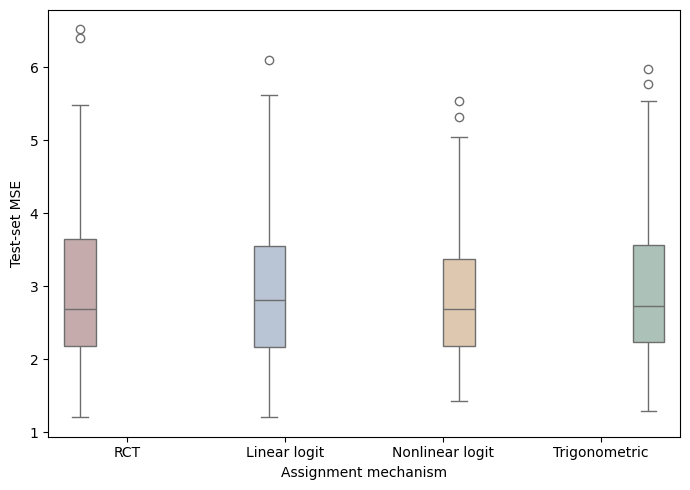

In [ ]:
df_table_assignments = pd.DataFrame(rows)
if 'mses' in df_table_assignments.columns:
    df_plot = (
        df_table_assignments[['assignment', 'mses']]
        .explode('mses')
        .rename(columns={'mses': 'MSE'})
    )
else:
    df_plot = pd.DataFrame(mse_records)

df_plot['Assignment'] = pd.Categorical(
    df_plot['assignment'].map(assignment_labels),
    categories=[assignment_labels[a] for a in assignment_types],
    ordered=True,
)

os.makedirs('results_sims', exist_ok=True)
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_plot,
    x='Assignment',
    y='MSE',
    hue='Assignment',
    palette=['#C9A7A7', '#B4C4D9', '#E6C9A8', '#A8C5B8'],
    legend=False,
)
plt.xlabel('Assignment mechanism')
plt.ylabel('Test-set MSE')
plt.tight_layout()
plt.savefig('results_sims/box_assignment_mse.pdf', dpi=300, bbox_inches='tight')
plt.savefig('results_sims/box_assignment_mse.png', dpi=300, bbox_inches='tight')
plt.show()


## Robustness to Noise

In [ ]:
import importlib
import generativeAI
importlib.reload(generativeAI)
from generativeAI import simulate_causal_snr

SEED = 232
snr_values = [0.1, 0.25, 0.5, 0.75, 1.0]
n_samples = 500
n_features = 20
n_mc = 100

rows = []
mse_records = []
for snr in snr_values:
    print('SNR:', snr)
    mse_list = []
    for rep in range(n_mc):
        rng_rep = SEED + rep
        X, D, Y, tau_true = simulate_causal_snr(
            n_samples=n_samples,
            n_features=n_features,
            snr=snr,
            effect='non-linear interaction',
            random_state=rng_rep,
        )
        X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
            X, D, Y, tau_true, test_size=0.5, random_state=rng_rep, stratify=D,
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        ens = CausalEnsemble(
            model_cls=CausalIQN,
            model_kwargs={'xdim': X_train.shape[1], 'hsz': 64, 'nh': 32},
            n_models=3,
            device='auto',
        )
        ens.fit(X_train, Y_train, D_train, epochs=500, lr=0.01,
                weight_decay=1e-3, verbose=False)
        tau_hat = ens.estimate_qte(X_test).mean(axis=1).astype(np.float32)
        mse_list.append(np.mean((tau_hat - tau_test)**2))

    for mse in mse_list:
        mse_records.append({'snr': snr, 'MSE': mse})
    rows.append({
        'snr': snr,
        'mses': list(mse_list),
        'GenTE MSE': np.mean(mse_list),
        'GenTE MSE std': np.std(mse_list),
    })
    print(f"  GenTE {np.mean(mse_list):.4f} ± {np.std(mse_list):.4f}")

df_table_snr = pd.DataFrame(rows)
for _, row in df_table_snr.iterrows():
    print(f"SNR {row['snr']}: GenTE {row['GenTE MSE']:.4f} ± {row['GenTE MSE std']:.4f}")


SNR: 0.1
  GenTE 9.8847 ± 7.7590
SNR: 0.25
  GenTE 6.0593 ± 3.0277
SNR: 0.5
  GenTE 4.7078 ± 1.8273
SNR: 0.75
  GenTE 4.1066 ± 1.4081
SNR: 1.0
  GenTE 3.8711 ± 1.3311
SNR 0.1: GenTE 9.8847 ± 7.7590
SNR 0.25: GenTE 6.0593 ± 3.0277
SNR 0.5: GenTE 4.7078 ± 1.8273
SNR 0.75: GenTE 4.1066 ± 1.4081
SNR 1.0: GenTE 3.8711 ± 1.3311


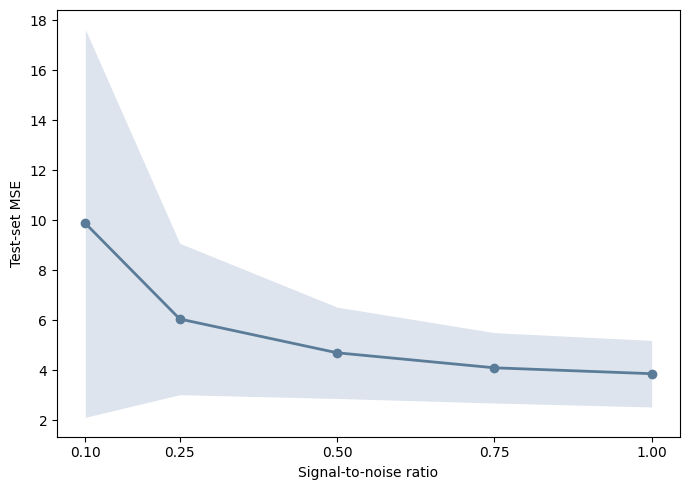

In [ ]:
df_plot = df_table_snr.sort_values('snr')
x = df_plot['snr'].to_numpy()
y = df_plot['GenTE MSE'].to_numpy()
s = df_plot['GenTE MSE std'].to_numpy()

os.makedirs('results_sims', exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(x, y - s, y + s, color='#B4C4D9', alpha=0.45, linewidth=0)
ax.plot(x, y, color='#5B7C99', marker='o', lw=2)
ax.set_xlabel('Signal-to-noise ratio')
ax.set_ylabel('Test-set MSE')
ax.set_xticks(x)
fig.tight_layout()
fig.savefig('results_sims/line_snr_mse.pdf', dpi=300, bbox_inches='tight')
fig.savefig('results_sims/line_snr_mse.png', dpi=300, bbox_inches='tight')
plt.show()
